##Install & import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Data splitting
from sklearn.model_selection import train_test_split, cross_validate
# Preprocessing
from sklearn.preprocessing import StandardScaler
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)
df = pd.read_csv('customer_churn_dataset_W7.csv')
sns.set_theme(style='whitegrid')
print('Libraries loaded ')

Libraries loaded 


In [4]:
# Upload your file
from google.colab import files
uploaded = files.upload()  # Upload exercise.csv here

## 1. Load Dataset

In [5]:
df = pd.read_csv('customer_churn_dataset_W7.csv')
print('Dataset loaded ')
print(df.head())

Dataset loaded 
  CustomerID  Gender   Age  MonthlyCharges ContractType  TenureMonths  \
0     C00001    Male  20.0           41.38      Monthly            16   
1     C00002  Female  24.0           45.75     Two-Year             3   
2     C00003  Female  42.0           34.32     Monthly              4   
3     C00004  Female  23.0           36.59      Monthly             6   
4     C00005    Male  51.0           66.38     Two-Year            13   

  PaymentMethod  SupportCalls  SatisfactionScore Churn  
0   Credit Card             5                6.0    No  
1          Cash             1                7.0    No  
2   Credit Card             2                5.0    No  
3           NaN             3                4.0    No  
4   Credit Card             1                6.0    No  



1. There are over 1000 observations and 10 variables are present.
2. Our target variable is churn.
3. Types of variables are include are categorical, numerical and Identifier Variable.
4. Each variable represent :
* Numerical: age, monthly_charges, tenure
* Categorical: contract, internet_service
* Binary: churn


# + Access Data quality and finding problem

In [6]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         10200 non-null  object 
 1   Gender             10200 non-null  object 
 2   Age                9694 non-null   float64
 3   MonthlyCharges     9698 non-null   float64
 4   ContractType       10200 non-null  object 
 5   TenureMonths       10200 non-null  int64  
 6   PaymentMethod      9704 non-null   object 
 7   SupportCalls       10200 non-null  int64  
 8   SatisfactionScore  9691 non-null   float64
 9   Churn              10200 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 797.0+ KB
None
               Age  MonthlyCharges  TenureMonths  SupportCalls  \
count  9694.000000     9698.000000  10200.000000  10200.000000   
mean     38.234578       74.405535     12.376569      2.486667   
std      13.817862      221.907514     11.551683

# + Show Missing values and Duplicates

In [7]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

# Show duplicate rows
print("\nDuplicate rows:")
print(df[df.duplicated()])

for col in ['Gender', 'ContractType', 'PaymentMethod']:
    print(f"\n{col}: {df[col].unique()}")

print("\nStats:\n", df[['Age', 'MonthlyCharges', 'SatisfactionScore']].agg(['min', 'max']))

Missing values:
 CustomerID             0
Gender                 0
Age                  506
MonthlyCharges       502
ContractType           0
TenureMonths           0
PaymentMethod        496
SupportCalls           0
SatisfactionScore    509
Churn                  0
dtype: int64

Duplicates: 200

Duplicate rows:
      CustomerID  Gender   Age  MonthlyCharges ContractType  TenureMonths  \
10000     C06253    Male  52.0           94.56      Monthly            72   
10001     C04685  Female  29.0           45.61      Monthly            11   
10002     C01732  Female  36.0          131.11      Monthly             6   
10003     C04743    Male  35.0           50.18      Monthly             9   
10004     C04522  Female  19.0           69.32      Monthly             5   
...          ...     ...   ...             ...          ...           ...   
10195     C04517  Female  31.0           65.73      Monthly             3   
10196     C01262  Female  36.0           62.92      Monthly           

# + Inconsistent Categories

In [8]:
df['Gender'].value_counts()
df['Gender'].unique()

array(['Male', 'Female', 'F', 'M', 'FEMALE', 'male'], dtype=object)

In [9]:
df['ContractType'].value_counts()
df['ContractType'].unique()

array(['Monthly', 'Two-Year', ' Monthly ', 'Yearly'], dtype=object)

In [10]:
df['PaymentMethod'].value_counts()
df['PaymentMethod'].unique()

array(['Credit Card', 'Cash', nan, 'Bank Transfer', 'E-Wallet',
       ' E-Wallet', 'Credit Card '], dtype=object)

In [11]:
# Check all categorical columns for inconsistent categories
categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    print(f"Column: {col}")
    print(df[col].value_counts(dropna=False))
    print("Unique values:")
    print(df[col].unique())

Column: CustomerID
CustomerID
C00953    2
C02250    2
C08792    2
C04203    2
C09656    2
         ..
C03373    1
C03374    1
C03375    1
C03376    1
C03367    1
Name: count, Length: 10000, dtype: int64
Unique values:
['C00001' 'C00002' 'C00003' ... 'C09998' 'C09999' 'C10000']
Column: Gender
Gender
Male      5123
Female    4570
male       152
FEMALE     151
M          102
F          102
Name: count, dtype: int64
Unique values:
['Male' 'Female' 'F' 'M' 'FEMALE' 'male']
Column: ContractType
ContractType
Monthly      7099
Yearly       1953
Two-Year     1047
 Monthly      101
Name: count, dtype: int64
Unique values:
['Monthly' 'Two-Year' ' Monthly ' 'Yearly']
Column: PaymentMethod
PaymentMethod
Credit Card      3808
E-Wallet         2400
Bank Transfer    2360
Cash              930
NaN               496
 E-Wallet         104
Credit Card       102
Name: count, dtype: int64
Unique values:
['Credit Card' 'Cash' nan 'Bank Transfer' 'E-Wallet' ' E-Wallet'
 'Credit Card ']
Column: Churn
Churn
No 

# Invalid Value

In [12]:
df.describe(include='all')
df['Gender'].value_counts()

,count
Gender,
Male,5123
Female,4570
male,152
FEMALE,151
M,102
F,102


# Outlier

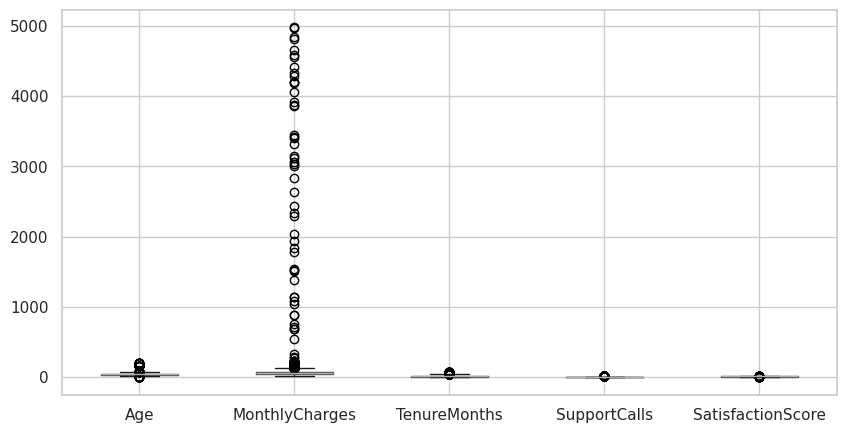

In [13]:
df.boxplot(figsize=(10,5))
plt.show()

# Scale Different

In [14]:
df.corr(numeric_only=True)

,Age,MonthlyCharges,TenureMonths,SupportCalls,SatisfactionScore
Age,1.000000,-0.006324,-0.000175,-0.022713,-0.009744
MonthlyCharges,-0.006324,1.000000,-0.002533,0.020768,0.010707
TenureMonths,-0.000175,-0.002533,1.000000,0.001829,-0.004063
SupportCalls,-0.022713,0.020768,0.001829,1.000000,0.005673
SatisfactionScore,-0.009744,0.010707,-0.004063,0.005673,1.000000


### Investigate Data leakage

* Data leakage occurs when information from outside the training dataset is used to create the model.
* Examples include preprocessing before train-test split or using post-churn variables.
* Train-test splitting must be done first to ensure fair model evaluation.
* Variables such as satisfaction score collected after churn could introduce leakage.

# Data cleaning



In [15]:
# --- Start of Data Cleaning ---
# Remove outliers
df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]
cap = df['MonthlyCharges'].quantile(0.99)
df = df[df['MonthlyCharges'] <= cap]
df = df[(df['SatisfactionScore'] >= 1) & (df['SatisfactionScore'] <= 10)]
df = df[df['SupportCalls'] >= 0]

# remove duplicates
df = df.drop_duplicates()

# handlig mssing values (example: drop)
df = df.dropna()

# standardize text formatting
df["Gender"] = df["Gender"].str.strip().str.title()
df["ContractType"] = df["ContractType"].str.strip().str.title()
df["PaymentMethod"] = df["PaymentMethod"].str.strip().str.title()
# --- End of Data Cleaning ---

df['SupportCallsPerMonth'] = df['SupportCalls'] / df['TenureMonths'].replace(0, 1)

print("Cleaned DataFrame head:")
display(df.head())

Cleaned DataFrame head:


,CustomerID,Gender,Age,MonthlyCharges,ContractType,TenureMonths,PaymentMethod,SupportCalls,SatisfactionScore,Churn,SupportCallsPerMonth
0,C00001,Male,20.0,41.38,Monthly,16,Credit Card,5,6.0,No,0.312500
1,C00002,Female,24.0,45.75,Two-Year,3,Cash,1,7.0,No,0.333333
2,C00003,Female,42.0,34.32,Monthly,4,Credit Card,2,5.0,No,0.500000
4,C00005,Male,51.0,66.38,Two-Year,13,Credit Card,1,6.0,No,0.076923
5,C00006,Male,37.0,57.93,Monthly,21,Bank Transfer,5,6.0,No,0.238095


# Exploratory Data Analysis


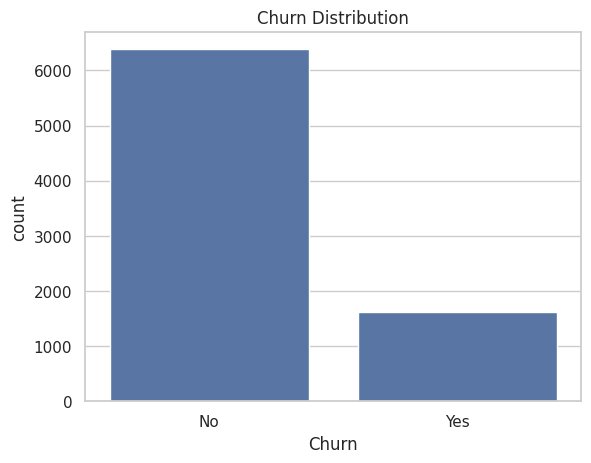

In [16]:
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.show()

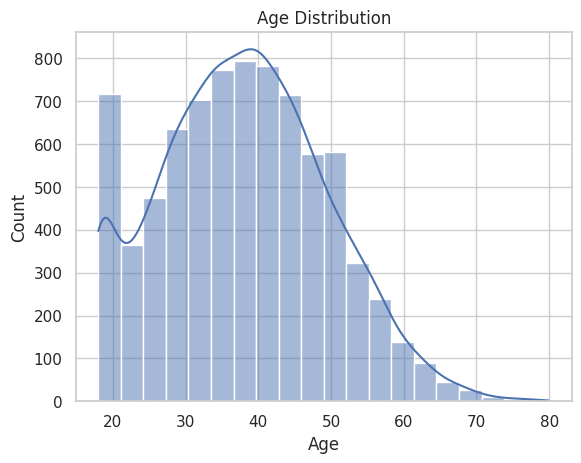

In [17]:
sns.histplot(df["Age"], bins=20
, kde=True)
plt.title("Age Distribution")
plt.show()

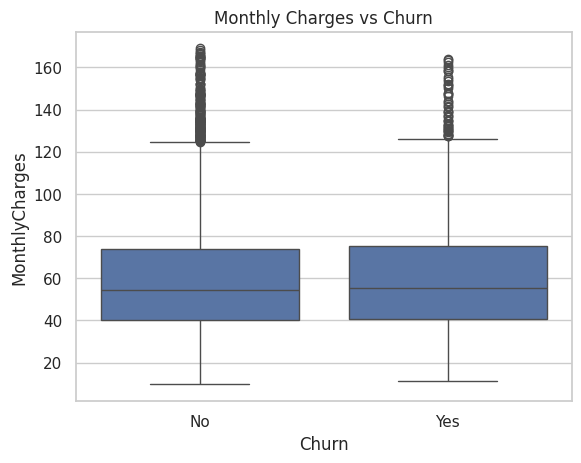

In [18]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

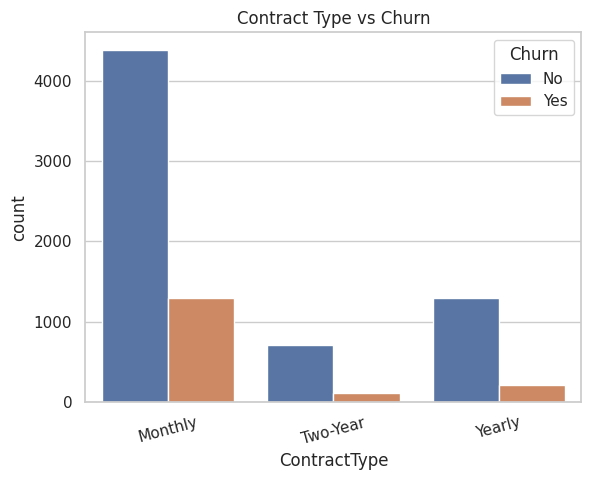

In [19]:
sns.countplot(data=df, x="ContractType", hue="Churn")
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

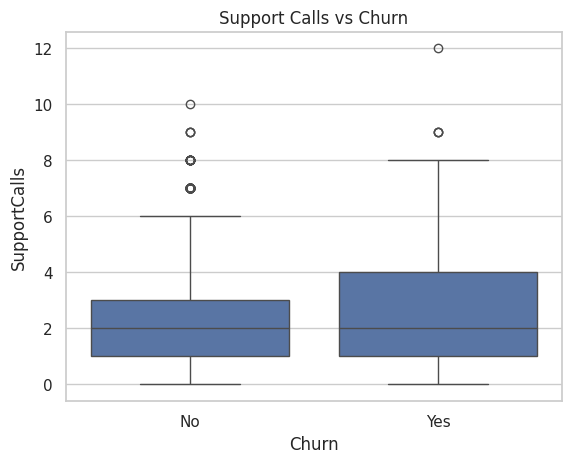

In [20]:
sns.boxplot(data=df, x="Churn", y="SupportCalls")
plt.title("Support Calls vs Churn")
plt.show()

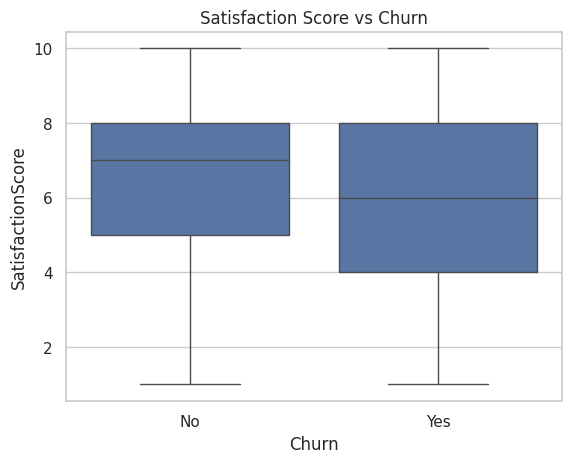

In [21]:
sns.boxplot(data=df, x="Churn", y="SatisfactionScore")
plt.title("Satisfaction Score vs Churn")
plt.show()

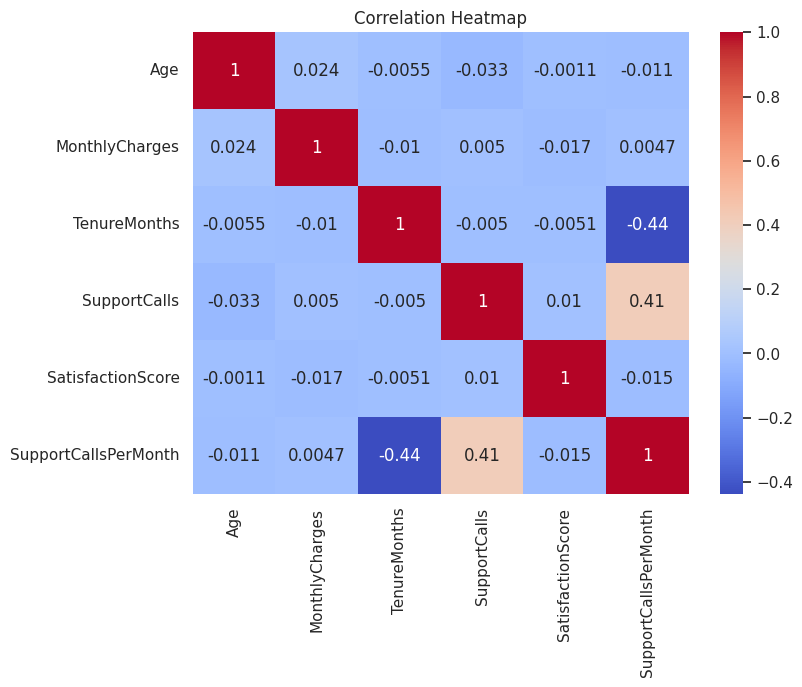

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

### Create appropriate visualizations to explore:
- Churn distribution
- Age
- monthlyCharges
- contact type
- support calls
- satisfaction score
# For each visualization
- describe the pattern observed
- discuss its potential relationship with churn

# Train-Test Split

In [23]:
# Perform train-test split on the cleaned DataFrame
X, y = df.drop(columns=['Churn']), df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Convert y_train and y_test to numerical (0/1)
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Churn ratio — Train: {y_train.value_counts(normalize=True)[1]*100:.1f}%, Test: {y_test.value_counts(normalize=True)[1]*100:.1f}%")

Train: (6397, 10), Test: (1600, 10)
Churn ratio — Train: 20.2%, Test: 20.2%


# Improve feature

In [24]:
# 1. Tenure Group

bins = [0, 12, 24, 48, 200]
labels = ['0-12 months', '13-24 months', '25-48 months', '49+ months']

X_train['TenureGroup'] = pd.cut(X_train['TenureMonths'], bins=bins, labels=labels, right=True)
X_test['TenureGroup'] = pd.cut(X_test['TenureMonths'], bins=bins, labels=labels, right=True)

churn_by_tenure = (
    X_train.assign(Churn=y_train)
    .groupby('TenureGroup', observed=True)['Churn']
    .apply(lambda s: (s == 1).mean() * 100) # Changed 'Yes' to 1 as y_train is numerical
    .round(2)
)
print(X_train['TenureGroup'].value_counts())
print("\nChurn rate (%) by Tenure Group:")
print(churn_by_tenure)

TenureGroup
0-12 months     4058
13-24 months    1463
25-48 months     758
49+ months       118
Name: count, dtype: int64

Churn rate (%) by Tenure Group:
TenureGroup
0-12 months     21.61
13-24 months    17.16
25-48 months    18.21
49+ months      19.49
Name: Churn, dtype: float64


In [25]:
# 2. SupportCall & Charge Ratios

# CallsPerMonth: normalizes support calls by how long the customer has been around
X_train['CallsPerMonth'] = X_train['SupportCalls'] / (X_train['TenureMonths'] + 1)
X_test['CallsPerMonth'] = X_test['SupportCalls'] / (X_test['TenureMonths'] + 1)

# IsNewCustomer: churn risk is often highest in the first few months
X_train['IsNewCustomer'] = (X_train['TenureMonths'] < 3).astype(int)
X_test['IsNewCustomer'] = (X_test['TenureMonths'] < 3).astype(int)

# NewCustomer_HighCalls: interaction -- new customers who ALSO call support a lot are extra high-risk
X_train['NewCustomer_HighCalls'] = X_train['IsNewCustomer'] * X_train['SupportCalls']
X_test['NewCustomer_HighCalls'] = X_test['IsNewCustomer'] * X_test['SupportCalls']

# ChargePerTenure: a high monthly charge early on may drive churn faster
X_train['ChargePerTenure'] = X_train['MonthlyCharges'] / (X_train['TenureMonths'] + 1)
X_test['ChargePerTenure'] = X_test['MonthlyCharges'] / (X_test['TenureMonths'] + 1)

new_features = ['CallsPerMonth', 'IsNewCustomer', 'NewCustomer_HighCalls', 'ChargePerTenure']
print("New features added:", new_features)
X_train[new_features].describe()

New features added: ['CallsPerMonth', 'IsNewCustomer', 'NewCustomer_HighCalls', 'ChargePerTenure']


,CallsPerMonth,IsNewCustomer,NewCustomer_HighCalls,ChargePerTenure
count,6397.000000,6397.000000,6397.000000,6397.000000
mean,0.385864,0.157730,0.401438,9.205560
std,0.467523,0.364516,1.124039,9.817298
min,0.000000,0.000000,0.000000,0.315588
25%,0.095238,0.000000,0.000000,2.904706
50%,0.222222,0.000000,0.000000,5.670000
75%,0.500000,0.000000,0.000000,11.783333
max,4.000000,1.000000,12.000000,83.150000


# Baseline Model

In [26]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42, stratify=y)

# Convert target to 0/1
target_map = {"Yes": 1, "No": 0}
y_train = y_train.map(target_map).astype(int)
y_test = y_test.map(target_map).astype(int)

# Categorical features
cat_features = ["Gender", "ContractType", "PaymentMethod"]

# One-hot encoding
X_tr_enc = pd.get_dummies(
    X_train,
    columns=cat_features,
    drop_first=True,
    dtype=int
)

X_te_enc = pd.get_dummies(
    X_test,
    columns=cat_features,
    drop_first=True,
    dtype=int
)

# Ensure train and test have identical columns
X_tr_enc, X_te_enc = X_tr_enc.align(
    X_te_enc,
    join="left",
    axis=1,
    fill_value=0
)

print("Encoding completed")
print(f"Training samples : {X_tr_enc.shape[0]}")
print(f"Testing samples  : {X_te_enc.shape[0]}")
print(f"Total features   : {X_tr_enc.shape[1]}")

Encoding completed
Training samples : 6397
Testing samples  : 1600
Total features   : 15


In [27]:
# Scale numerical features
from sklearn.preprocessing import StandardScaler

num_features = [
    "Age",
    "MonthlyCharges",
    "TenureMonths",
    "SupportCalls",
    "SatisfactionScore"
]

scaler = StandardScaler()

X_tr_enc[num_features] = scaler.fit_transform(X_tr_enc[num_features])
X_te_enc[num_features] = scaler.transform(X_te_enc[num_features])

print("Feature scaling completed")

Feature scaling completed


In [28]:
# Train Logistic Regression
model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

model.fit(X_tr_final, y_train)

print("Logistic Regression model trained")
print(f"Training samples : {len(y_train)}")
print(f"Number of features : {X_tr_final.shape[1]}")

NameError: name 'X_tr_final' is not defined

# Model Evaluation

In [ ]:
df['target'] = df['Churn'].map({'Yes': 1, 'No': 0})

X = df.drop(columns=['CustomerID', 'Churn', 'target'], errors='ignore')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X.select_dtypes(include=['float64', 'int64']),
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

print("BALANCED MODEL")
print(" ")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
models = {
    "Logistic Regression": log_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

plt.figure(figsize=(8, 6))

for name, model in models.items():

    # Predicted probabilities
    y_prob = model.predict_proba(X_te_final)[:, 1]

    # ROC metrics
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    # Plot ROC curve
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.2f})")

# Random classifier
plt.plot([0, 1], [0, 1], "k--", label="Random Guess (AUC = 0.50)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Cross Validation

In [ ]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

# Evaluation metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_tr_final,
        y_train,
        cv=5,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    result = {"Model": name}

    for metric in scoring:
        result[f"{metric} (mean)"] = scores[f"test_{metric}"].mean()
        result[f"{metric} (std)"] = scores[f"test_{metric}"].std()

    cv_results.append(result)

cv_df = pd.DataFrame(cv_results).round(4)

display(cv_df.sort_values("recall (mean)", ascending=False))